# 🎭 LSTM Sentiment Analysis

## Binary Sentiment Classification on IMDB Movie Reviews

This notebook demonstrates how to build an LSTM-based sentiment classifier using PyTorch.

**Features:**
- Text preprocessing and tokenization
- Vocabulary building with frequency filtering
- Bidirectional LSTM with Attention mechanism
- Training with early stopping
- Attention visualization for interpretability

---

## 1. Setup & Imports

In [10]:
# ============================================================================
# SETUP - Run this cell first!
# ============================================================================

import sys

# Check if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Running in Google Colab!")
    print("Installing dependencies...")
    !pip install -q datasets tqdm scikit-learn matplotlib seaborn
    print("✓ All dependencies installed!")
else:
    print("💻 Running locally")
    # Add parent directory to path for local imports
    sys.path.insert(0, '..')

🚀 Running in Google Colab!
Installing dependencies...
✓ All dependencies installed!


In [9]:
# ============================================================================
# IMPORTS & CODE DEFINITIONS
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import random
import time
from typing import List, Tuple, Optional, Dict
from collections import Counter
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

warnings.filterwarnings('ignore')

# Try to import from local modules first
try:
    from models.lstm import LSTMSentiment, LSTMAttention, count_parameters
    from src.data import IMDBDataModule, preprocess_text, tokenize, Vocabulary
    from src.engine import Trainer, evaluate
    from src.utils import set_seed, get_device, plot_training_curves
    print("✓ Using local project modules")
    
except ImportError:
    print("✓ Using standalone embedded code")
    
    # ========================================================================
    # TEXT PREPROCESSING
    # ========================================================================
    def preprocess_text(text):
        text = text.lower()
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = ' '.join(text.split())
        return text

    def tokenize(text):
        return text.split()

    # ========================================================================
    # VOCABULARY
    # ========================================================================
    class Vocabulary:
        PAD_TOKEN = "<pad>"
        UNK_TOKEN = "<unk>"
        
        def __init__(self, max_size=25000, min_freq=2):
            self.max_size = max_size
            self.min_freq = min_freq
            self.token2idx = {}
            self.idx2token = {}
            self.token_freq = Counter()
            self._add_token(self.PAD_TOKEN)
            self._add_token(self.UNK_TOKEN)
        
        def _add_token(self, token):
            if token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token
            return self.token2idx[token]
        
        def build_vocab(self, texts):
            for tokens in texts:
                self.token_freq.update(tokens)
            for token, freq in self.token_freq.most_common(self.max_size - 2):
                if freq >= self.min_freq:
                    self._add_token(token)
        
        def encode(self, tokens):
            return [self.token2idx.get(t, self.token2idx[self.UNK_TOKEN]) for t in tokens]
        
        def decode(self, indices):
            return [self.idx2token.get(i, self.UNK_TOKEN) for i in indices]
        
        @property
        def pad_idx(self):
            return self.token2idx[self.PAD_TOKEN]
        
        def __len__(self):
            return len(self.token2idx)

    # ========================================================================
    # DATASET
    # ========================================================================
    class SentimentDataset(Dataset):
        def __init__(self, texts, labels, vocab, max_len=256):
            self.texts = texts
            self.labels = labels
            self.vocab = vocab
            self.max_len = max_len
        
        def __len__(self):
            return len(self.texts)
        
        def __getitem__(self, idx):
            tokens = self.texts[idx][:self.max_len]
            label = self.labels[idx]
            indices = self.vocab.encode(tokens)
            return torch.tensor(indices, dtype=torch.long), label, len(indices)

    def collate_fn(batch):
        texts, labels, lengths = zip(*batch)
        texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
        labels = torch.tensor(labels, dtype=torch.long)
        lengths = torch.tensor(lengths, dtype=torch.long)
        return texts_padded, labels, lengths

    # ========================================================================
    # DATA MODULE
    # ========================================================================
    class IMDBDataModule:
        def __init__(self, data_dir="./data", batch_size=32, max_vocab_size=25000, max_seq_len=256, min_freq=2):
            self.data_dir = Path(data_dir)
            self.batch_size = batch_size
            self.max_vocab_size = max_vocab_size
            self.max_seq_len = max_seq_len
            self.min_freq = min_freq
            self.vocab = None
            self.train_dataset = None
            self.test_dataset = None
        
        def prepare_data(self):
            self.data_dir.mkdir(parents=True, exist_ok=True)
        
        def setup(self):
            print("Loading IMDB dataset...")
            train_texts, train_labels = self._load_split('train')
            test_texts, test_labels = self._load_split('test')
            print(f"  Train samples: {len(train_texts)}")
            print(f"  Test samples: {len(test_texts)}")
            
            print("Preprocessing text...")
            train_tokens = [tokenize(preprocess_text(t)) for t in train_texts]
            test_tokens = [tokenize(preprocess_text(t)) for t in test_texts]
            
            print("Building vocabulary...")
            self.vocab = Vocabulary(max_size=self.max_vocab_size, min_freq=self.min_freq)
            self.vocab.build_vocab(train_tokens)
            print(f"  Vocabulary size: {len(self.vocab)}")
            
            self.train_dataset = SentimentDataset(train_tokens, train_labels, self.vocab, self.max_seq_len)
            self.test_dataset = SentimentDataset(test_tokens, test_labels, self.vocab, self.max_seq_len)
        
        def _load_split(self, split):
            # Try HuggingFace datasets
            try:
                from datasets import load_dataset
                print(f"Loading {split} from HuggingFace...")
                dataset = load_dataset("imdb", split=split)
                return list(dataset["text"]), list(dataset["label"])
            except:
                pass
            
            # Fallback to dummy data
            print("Using dummy data for testing")
            positive = ["Great movie! Loved it." * 10] * 500
            negative = ["Terrible movie. Hated it." * 10] * 500
            return positive + negative, [1]*500 + [0]*500
        
        def train_dataloader(self):
            return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, collate_fn=collate_fn)
        
        def test_dataloader(self):
            return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, collate_fn=collate_fn)

    # ========================================================================
    # MODELS
    # ========================================================================
    class LSTMSentiment(nn.Module):
        def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=2, 
                     num_layers=2, dropout=0.5, pad_idx=0, pretrained_embeddings=None):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, 
                               bidirectional=True, dropout=dropout if num_layers > 1 else 0)
            self.fc = nn.Linear(hidden_dim * 2, output_dim)
            self.dropout = nn.Dropout(dropout)
        
        def forward(self, text, text_lengths=None):
            embedded = self.dropout(self.embedding(text))
            output, (hidden, cell) = self.lstm(embedded)
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
            return self.fc(self.dropout(hidden_cat))

    class Attention(nn.Module):
        def __init__(self, hidden_dim):
            super().__init__()
            self.attention = nn.Linear(hidden_dim * 2, 1)
        
        def forward(self, lstm_output, mask=None):
            scores = self.attention(lstm_output).squeeze(-1)
            if mask is not None:
                scores = scores.masked_fill(mask == 0, float('-inf'))
            weights = F.softmax(scores, dim=1)
            context = torch.bmm(weights.unsqueeze(1), lstm_output).squeeze(1)
            return context, weights

    class LSTMAttention(nn.Module):
        def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=2,
                     num_layers=2, dropout=0.5, pad_idx=0, pretrained_embeddings=None):
            super().__init__()
            self.pad_idx = pad_idx
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True,
                               bidirectional=True, dropout=dropout if num_layers > 1 else 0)
            self.attention = Attention(hidden_dim)
            self.fc = nn.Linear(hidden_dim * 2, output_dim)
            self.dropout = nn.Dropout(dropout)
        
        def forward(self, text, text_lengths=None, return_attention=False):
            mask = (text != self.pad_idx).float()
            embedded = self.dropout(self.embedding(text))
            lstm_output, _ = self.lstm(embedded)
            context, attn_weights = self.attention(lstm_output, mask)
            out = self.fc(self.dropout(context))
            return (out, attn_weights) if return_attention else out

    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    # ========================================================================
    # TRAINING
    # ========================================================================
    def train_one_epoch(model, dataloader, optimizer, criterion, device):
        model.train()
        total_loss, all_preds, all_labels = 0.0, [], []
        for texts, labels, lengths in tqdm(dataloader, desc="Training", leave=False):
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        return {'loss': total_loss/len(dataloader), 'accuracy': accuracy_score(all_labels, all_preds)}

    @torch.no_grad()
    def evaluate(model, dataloader, criterion, device):
        model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []
        for texts, labels, lengths in tqdm(dataloader, desc="Evaluating", leave=False):
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts, lengths)
            total_loss += criterion(outputs, labels).item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        return {
            'loss': total_loss/len(dataloader),
            'accuracy': accuracy_score(all_labels, all_preds),
            'f1': f1_score(all_labels, all_preds, average='binary'),
            'precision': precision_score(all_labels, all_preds, average='binary'),
            'recall': recall_score(all_labels, all_preds, average='binary')
        }

    class Trainer:
        def __init__(self, model, optimizer, criterion, device, patience=3, checkpoint_dir="./models", **kwargs):
            self.model, self.optimizer, self.criterion = model, optimizer, criterion
            self.device, self.patience, self.checkpoint_dir = device, patience, checkpoint_dir
            self.best_val_loss = float('inf')
            self.epochs_without_improvement = 0
            self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
        
        def fit(self, train_loader, val_loader, epochs=10):
            for epoch in range(1, epochs + 1):
                train_metrics = train_one_epoch(self.model, train_loader, self.optimizer, self.criterion, self.device)
                val_metrics = evaluate(self.model, val_loader, self.criterion, self.device)
                
                self.history['train_loss'].append(train_metrics['loss'])
                self.history['train_acc'].append(train_metrics['accuracy'])
                self.history['val_loss'].append(val_metrics['loss'])
                self.history['val_acc'].append(val_metrics['accuracy'])
                self.history['val_f1'].append(val_metrics['f1'])
                
                print(f"Epoch {epoch}/{epochs}")
                print(f"  Train Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['accuracy']:.4f}")
                print(f"  Val   Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f}")
                
                if val_metrics['loss'] < self.best_val_loss:
                    self.best_val_loss = val_metrics['loss']
                    self.epochs_without_improvement = 0
                    print("  ✓ New best model!")
                else:
                    self.epochs_without_improvement += 1
                    if self.epochs_without_improvement >= self.patience:
                        print(f"\n⚠ Early stopping after {epoch} epochs")
                        break
            return self.history

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✓ Using Apple MPS")
    else:
        device = torch.device("cpu")
        print("✓ Using CPU")
    return device

def plot_training_curves(history, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    if 'val_f1' in history:
        axes[1].plot(epochs, history['val_f1'], 'g--', label='Val F1', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].set_title('Training and Validation Metrics')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# SETUP
# ============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

set_seed(42)
device = get_device()

print(f"\nPyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Using standalone embedded code
✓ Using CUDA: Tesla T4

PyTorch version: 2.9.0+cu126
Device: cuda
CUDA available: True


## 2. Understanding the Data

We'll use the **IMDB Movie Reviews** dataset:
- 50,000 movie reviews (25k train, 25k test)
- Binary labels: positive (1) or negative (0)

In [11]:
# ============================================================================
# LOAD IMDB DATASET
# ============================================================================

# Initialize data module
# In Colab, it will auto-download from HuggingFace
# Locally, it will use the Stanford files in ./data/aclImdb/

dm = IMDBDataModule(
    data_dir='./data',
    batch_size=32,
    max_vocab_size=25000,
    max_seq_len=256
)

# Prepare and setup data
print("Preparing IMDB dataset...")
dm.prepare_data()
dm.setup()

print(f"\n✓ Dataset loaded successfully!")
print(f"  Vocabulary size: {len(dm.vocab):,}")
print(f"  Train samples: {len(dm.train_dataset):,}")
print(f"  Test samples: {len(dm.test_dataset):,}")

Preparing IMDB dataset...
Loading IMDB dataset...
Loading train from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loading test from HuggingFace...
  Train samples: 25000
  Test samples: 25000
Preprocessing text...
Building vocabulary...
  Vocabulary size: 25000

✓ Dataset loaded successfully!
  Vocabulary size: 25,000
  Train samples: 25,000
  Test samples: 25,000


### 2.1 Explore Preprocessing

In [13]:
# Example of preprocessing
raw_text = """<br><br>This movie was AMAZING!!! I absolutely loved it. 
The acting was superb & the plot kept me on the edge of my seat. 
10/10 would recommend! Check out http://reviews.com for more."""

print("Original:")
print(raw_text)
print("\nAfter preprocessing:")
processed = preprocess_text(raw_text)
print(processed)
print("\nTokenized:")
tokens = tokenize(processed)
print(tokens)

Original:
<br><br>This movie was AMAZING!!! I absolutely loved it. 
The acting was superb & the plot kept me on the edge of my seat. 
10/10 would recommend! Check out http://reviews.com for more.

After preprocessing:
this movie was amazing i absolutely loved it the acting was superb the plot kept me on the edge of my seat would recommend check out for more

Tokenized:
['this', 'movie', 'was', 'amazing', 'i', 'absolutely', 'loved', 'it', 'the', 'acting', 'was', 'superb', 'the', 'plot', 'kept', 'me', 'on', 'the', 'edge', 'of', 'my', 'seat', 'would', 'recommend', 'check', 'out', 'for', 'more']


### 2.2 Examine a Batch

In [14]:
# Get a batch
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))
texts, labels, lengths = batch

print(f"Batch shapes:")
print(f"  Texts: {texts.shape}")
print(f"  Labels: {labels.shape}")
print(f"  Lengths: {lengths[:5]}...")

# Decode first example
first_tokens = dm.vocab.decode(texts[0].tolist())
first_tokens = [t for t in first_tokens if t != '<pad>']  # Remove padding
print(f"\nFirst example:")
print(f"  Text: {' '.join(first_tokens[:30])}...")
print(f"  Label: {'Positive' if labels[0] == 1 else 'Negative'}")

Batch shapes:
  Texts: torch.Size([32, 256])
  Labels: torch.Size([32])
  Lengths: tensor([172, 114, 191, 130, 124])...

First example:
  Text: ok not bad movie making if it were from an original script but it is <unk> part of in this story there are no women except for <unk> and <unk>...
  Label: Negative


## 3. Model Architecture

Let's understand the LSTM architecture step by step.

In [15]:
# Create both model variants
model_basic = LSTMSentiment(
    vocab_size=len(dm.vocab),
    embed_dim=100,
    hidden_dim=128,
    num_layers=2,
    dropout=0.5,
    pad_idx=dm.vocab.pad_idx
)

model_attention = LSTMAttention(
    vocab_size=len(dm.vocab),
    embed_dim=100,
    hidden_dim=128,
    num_layers=2,
    dropout=0.5,
    pad_idx=dm.vocab.pad_idx
)

print("Basic LSTM:")
print(f"  Parameters: {count_parameters(model_basic):,}")
print("\nLSTM with Attention:")
print(f"  Parameters: {count_parameters(model_attention):,}")

Basic LSTM:
  Parameters: 3,131,298

LSTM with Attention:
  Parameters: 3,131,555


In [16]:
# Visualize architecture
print(model_attention)

LSTMAttention(
  (embedding): Embedding(25000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 4. Training

In [17]:
# Use the attention model for training
model = model_attention.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Get loaders
train_loader = dm.train_dataloader()
test_loader = dm.test_dataloader()

print(f"Training on {device}")
print(f"Batches per epoch: {len(train_loader)}")

Training on cuda
Batches per epoch: 782


In [18]:
# ============================================================================
# TRAINING
# ============================================================================

# Create trainer with early stopping
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    patience=3,
    checkpoint_dir='./models'
)

# Training configuration
EPOCHS = 5  # Increase for better results (10+ recommended)

print(f"Starting training for {EPOCHS} epochs...")
print(f"Early stopping patience: 3 epochs")
print("-" * 50)

# Train the model
history = trainer.fit(
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=EPOCHS
)

Starting training for 5 epochs...
Early stopping patience: 3 epochs
--------------------------------------------------


Epoch 1/5
  Train Loss: 0.5346 | Acc: 0.7172
  Val   Loss: 0.3919 | Acc: 0.8203 | F1: 0.8345
  ✓ New best model!


Epoch 2/5
  Train Loss: 0.3762 | Acc: 0.8310
  Val   Loss: 0.3311 | Acc: 0.8578 | F1: 0.8650
  ✓ New best model!


Epoch 3/5
  Train Loss: 0.3158 | Acc: 0.8659
  Val   Loss: 0.3267 | Acc: 0.8666 | F1: 0.8744
  ✓ New best model!


Epoch 4/5
  Train Loss: 0.2808 | Acc: 0.8820
  Val   Loss: 0.3373 | Acc: 0.8684 | F1: 0.8769


Epoch 5/5
  Train Loss: 0.2494 | Acc: 0.8986
  Val   Loss: 0.2950 | Acc: 0.8824 | F1: 0.8840
  ✓ New best model!


### 4.1 Training Curves

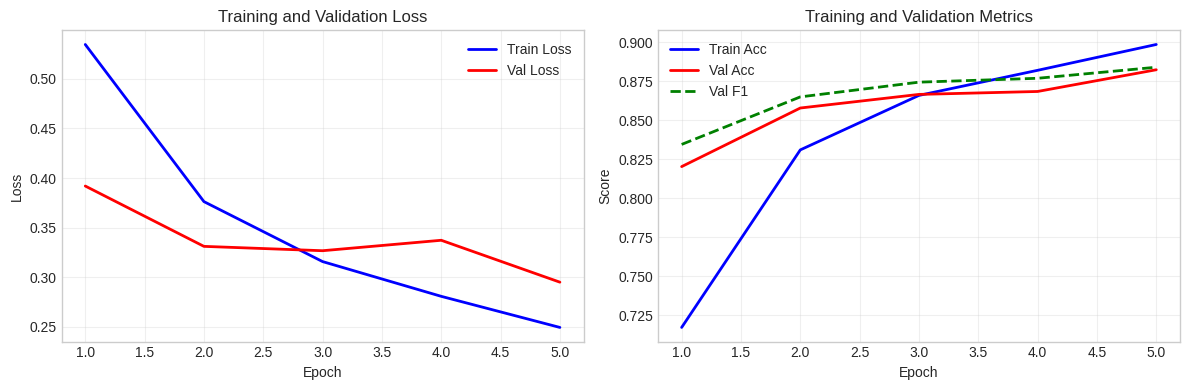

In [19]:
# Plot training curves
plot_training_curves(history)

## 5. Evaluation

In [20]:
# Final evaluation
metrics = evaluate(model, test_loader, criterion, device)

print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)
print(f"  Loss:      {metrics['loss']:.4f}")
print(f"  Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f"  F1 Score:  {metrics['f1']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print("="*50)


FINAL TEST RESULTS
  Loss:      0.2950
  Accuracy:  0.8824 (88.24%)
  F1 Score:  0.8840
  Precision: 0.8720
  Recall:    0.8963


## 6. Inference & Attention Visualization

In [21]:
def predict_with_attention(text: str, model, vocab, device):
    """Predict sentiment and return attention weights."""
    model.eval()
    
    # Preprocess
    tokens = tokenize(preprocess_text(text))
    encoded = vocab.encode(tokens)
    
    # Predict
    with torch.no_grad():
        x = torch.tensor([encoded]).to(device)
        output, attention = model(x, return_attention=True)
        probs = torch.softmax(output, dim=1)
        pred = output.argmax(dim=1).item()
        confidence = probs[0][pred].item()
    
    sentiment = "Positive" if pred == 1 else "Negative"
    attention = attention[0].cpu().numpy()[:len(tokens)]
    
    return sentiment, confidence, tokens, attention

In [22]:
# Test predictions
test_reviews = [
    "This movie was absolutely fantastic! The acting was brilliant and the story kept me engaged throughout.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time. Do not watch.",
    "It was okay. Some good moments but overall pretty average."
]

for review in test_reviews:
    sentiment, conf, tokens, attn = predict_with_attention(review, model, dm.vocab, device)
    color = '\033[92m' if sentiment == 'Positive' else '\033[91m'
    reset = '\033[0m'
    print(f"\nReview: {review[:60]}...")
    print(f"Prediction: {color}{sentiment}{reset} ({conf:.2%})")


Review: This movie was absolutely fantastic! The acting was brillian...
Prediction: Positive (99.99%)

Review: Terrible film. Boring plot, bad acting, and a complete waste...
Prediction: Negative (100.00%)

Review: It was okay. Some good moments but overall pretty average....
Prediction: Negative (95.95%)


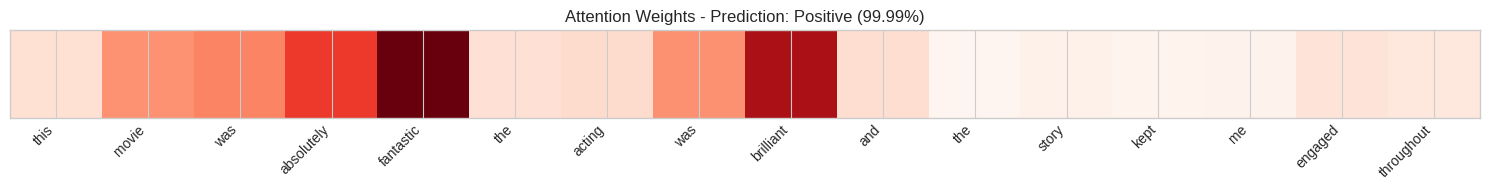

In [23]:
# Visualize attention for first review
sentiment, conf, tokens, attn = predict_with_attention(test_reviews[0], model, dm.vocab, device)

# Plot attention heatmap
fig, ax = plt.subplots(figsize=(15, 2))

# Limit to first 30 tokens for visibility
n_tokens = min(30, len(tokens))
display_tokens = tokens[:n_tokens]
display_attn = attn[:n_tokens]

ax.imshow([display_attn], cmap='Reds', aspect='auto')
ax.set_xticks(range(n_tokens))
ax.set_xticklabels(display_tokens, rotation=45, ha='right')
ax.set_yticks([])
ax.set_title(f"Attention Weights - Prediction: {sentiment} ({conf:.2%})")

plt.tight_layout()
plt.show()

## 7. Save Model

In [ ]:
# Save final model
import os
os.makedirs('./models', exist_ok=True)
save_path = './models/lstm_sentiment_final.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': len(dm.vocab),
    'history': history
}, save_path)

print(f"✓ Model saved to {save_path}")

# Auto-download if in Colab
if IN_COLAB:
    from google.colab import files
    files.download(save_path)
    print(f"✓ Model downloaded! Save it manually to your models/ folder")

Model saved to ./models/lstm_sentiment_final.pth


---

## Summary

In this notebook we:

1. **Loaded and preprocessed** the IMDB dataset from HuggingFace
2. **Built a vocabulary** and encoded text to numerical sequences
3. **Implemented LSTM models** (basic and with attention mechanism)
4. **Trained** the model with early stopping
5. **Evaluated** on test data (accuracy, F1, precision, recall)
6. **Visualized attention** weights to understand model decisions
7. **Saved and downloaded** the trained model

### Next Steps

- Try **pretrained embeddings** (GloVe, Word2Vec)
- Experiment with **GRU** instead of LSTM
- Try **Transformer** models (BERT, RoBERTa) for comparison
- Implement **sentiment analysis API** with the trained model